# Exercise 2. Regression using MLP


In this exercise, there are two tasks  related to creating neural networks. The purpose of the tasks is to get acquainted with regression using neural networks, i.e. to create a model that predicts different order equations.

Both tasks have a conclusion cell, in which you can write down the summary how different configuration (epochs, number of hidden layers, number of nodes in hidden layers)  affects the results. 



## TASK 1

Purpose is to create neural network (MLP) to model the second order equation: 

$$ f(x) = x^2 + 3$$



In [37]:
# Generate dataset for the range [-3,3] with 200 sample
# Implementation comes this cell
import numpy as np

X = np.linspace(-3, 3, 200).reshape(-1, 1) # input dataset
y = X**2 + 3 # target dataset

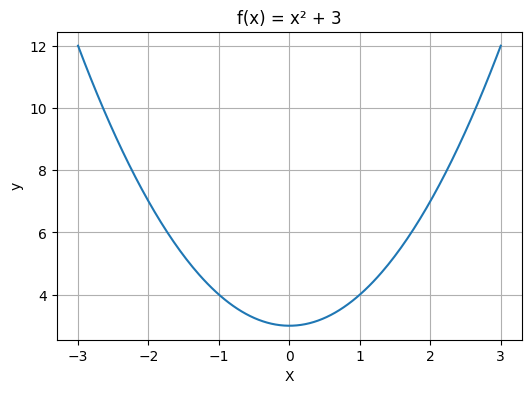

In [38]:
# Plot the sample
# Implementation comes to this cell
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
#plt.scatter(X, y)
plt.plot(X, y)
plt.title("f(x) = x² + 3")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [39]:
# Shuffle the dataset and split it:
# training set 80%
# test set 20%
# Implementation comes this cell
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

In [40]:
# Define neural network using Keras Function API
# Input layer = 1 node i.e. one feature, value of x-axis
# 1 hidden layer = 2-4 nodes.  Dense with 'relu' activation function in each hidden layer
# Second order equation is nonlinear function, so we can't use linear activation function. 
# Output layer = 1 node (due to regression, only one node is enought in the output layer)

# Implementation comes this cell
# Print the structure of model: model.summary()

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

inputs = Input(shape=(1,))
hidden = Dense(4, activation='relu')(inputs)
outputs = Dense(1)(hidden)
model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Compile with following parameters
# optimizer='adam', 
# loss='mean_squared_error',
# metrics=['mae'])
# Implementation comes this cell

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [42]:
# Fit model with 
# epochs: 100, 200, 300
# Implementation comes this cell
# history = model.fit(X_train, y_train, epochs=100)
# history = model.fit(X_train, y_train, epochs=200)
history = model.fit(X_train, y_train, epochs=300)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 42.9889 - mae: 5.9624  
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 42.6507 - mae: 5.9373
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 42.3218 - mae: 5.9128
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 41.9918 - mae: 5.8878
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 41.6604 - mae: 5.8631
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 41.3344 - mae: 5.8384
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 41.0050 - mae: 5.8138
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 40.6947 - mae: 5.7895
Epoch 9/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 40.3718 - mae: 5.7649
Epoch 10/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 40.0447 - mae: 5.7401
Epoch 11/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 39.7268 - mae: 5.7158
Epoch 12/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 39.4311 - mae: 5.6919
Epoch 13/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/st

In [43]:
# Evaluate()
# Implementation comes this cell
results = model.evaluate(X_test, y_test)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3945 - mae: 0.5870 


In [45]:
# Predict using 30 sample from range [-2,3]
# Implementation comes this cell
X_new = np.linspace(-2, 3, 30).reshape(-1, 1)
y_new_predicted = model.predict(X_new)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


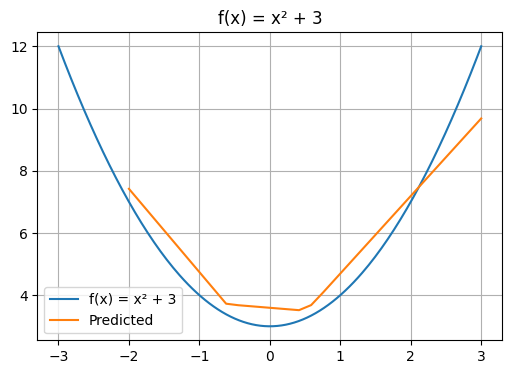

In [46]:
# Plot predicted values to same plot as the equation
# Implementation comes this cell
plt.figure(figsize=(6, 4))
plt.plot(X, y, label='f(x) = x² + 3')
plt.plot(X_new, y_new_predicted, label='Predicted')
plt.title("f(x) = x² + 3")
plt.grid(True)
plt.legend()
plt.show()


__Conclusion__

Short conclusion:
- How number of nodes in hidden layer affects the results?
More nodes allow the model to learn more complex patterns. In my experiments, with 2 nodes the test MSE stayed on the higher end regardless of how many epochs I trained for, showing the model lacked enough capacity to fit the curve. Adding just one more node (3 nodes) caused a big drop in test MSE. Increasing further to 4 nodes gave almost the same result as 3 nodes, so within the 2-4 node range I was given, 4 nodes gave the best result, at 300 epochs.

- How the number of epochs affects the results?
More epochs give the model more time to learn. With fewer epochs (100-200), the model was 
still underfitting, showing noticeably higher loss. Training for longer allowed the loss 
to drop sharply between 100 and 200 epochs. Beyond that, further training gave only small 
additional improvements, meaning the model was close to fully converged well before 300 
epochs. Overall, I found 300 epochs gave the best results within the range I was given.

The results were also not consistent between runs, because the model starts with random 
weights each time. So it is difficult to say if running the code again will produce 
similar results. To compare different node and epoch combinations more reliably, I ran 
additional experiments separately using a fixed random seed, which are not included in 
this notebook.

Note: I used an AI assistant to help me understand neural network concepts and to debug 
my code during this exercise. The experiments, results, and conclusions above are based 
on my own analysis of the model outputs.

## TASK 2

Purpose is to create neural network (MLP) to model the cubic (third) order equation: 

$$ f(x) = x^3 + 4x^2 - x + 2 $$


In [26]:
# Generate dataset for the range [-2,3] with 1000 sample
# Implementation comes this cell
import numpy as np

X = np.linspace(-2, 3, 1000).reshape(-1, 1) # input dataset
y = X**3 + 4*X**2 - X + 2 # target dataset

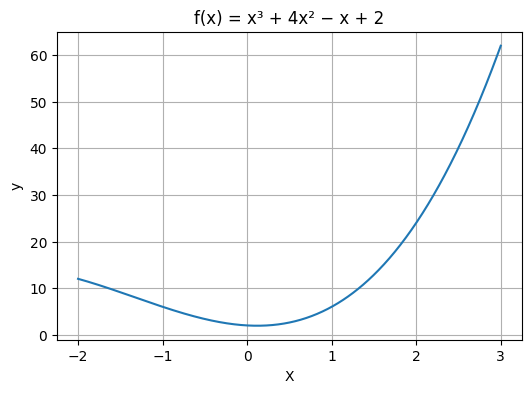

In [27]:
# Plot the sample
# Implementation comes to this cell
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
#plt.scatter(X, y)
plt.plot(X, y)
plt.title("f(x) = x³ + 4x² − x + 2")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [28]:
# Shuffle the dataset and split it:
# training set 80%
# test set 20%
# Implementation comes this cell
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

In [29]:
# Define neural network using Keras Function API
# Input layer = 1 node
# 1-2 hidden layer = 4-8 nodes. Dense with 'relu' activation function in each hidden layer
# Cubic equation is nonlinear function, so we can't use linear activation function. 
# Output layer = 1 node (due to regression, only one node is enought in the output layer)

# Implementation comes this cell
# Print the structure of model: model.summary()
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

inputs = Input(shape=(1,))
hidden1 = Dense(4, activation='relu')(inputs)
hidden2 = Dense(8, activation='relu')(hidden1)
outputs = Dense(1)(hidden2)
model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57 (228.00 B)

 Trainable params: 57 (228.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Compile with following parameters
# optimizer='adam', 
# loss='mean_squared_error',
# metrics=['mae'])
# Implementation comes this cell

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [ ]:
# Fit model with 
# epochs: 50, 100, 200
# Implementation comes this cell

# history = model.fit(X_train, y_train, epochs=50)
# history = model.fit(X_train, y_train, epochs=100)
history = model.fit(X_train, y_train, epochs=200)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - loss: 420.3668 - mae: 13.9734
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step - loss: 416.4077 - mae: 13.7816
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - loss: 412.2479 - mae: 13.5807
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step - loss: 407.9866 - mae: 13.3618
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step - loss: 403.6384 - mae: 13.1371
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 465us/step - loss: 399.1847 - mae: 12.8900
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step - loss: 394.4771 - mae: 12.6130
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - loss: 389.2282 - mae: 12.2674
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step - loss: 384.1318 - mae: 11.8937
Epoch 10/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 510us/step - loss: 379.4449 - mae: 11.5351
Epoch 11/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 486us/step - loss: 375.1624 - mae: 11.2349
Epoch 12/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 495us/step - loss: 3

In [36]:
# Evaluate()
# Implementation comes this cell
results = model.evaluate(X_test, y_test)
test_mse, test_mae = results
print(f"Test MSE: {test_mse:.4f}, Test MAE: {test_mae:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1026 - mae: 0.3470 
Test MSE: 1.1026, Test MAE: 0.3470


In [34]:
# Predict using 30 sample from range [-2,3]
# Implementation comes this cell

X_new = np.linspace(-2, 3, 30).reshape(-1, 1)
y_new_predicted = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


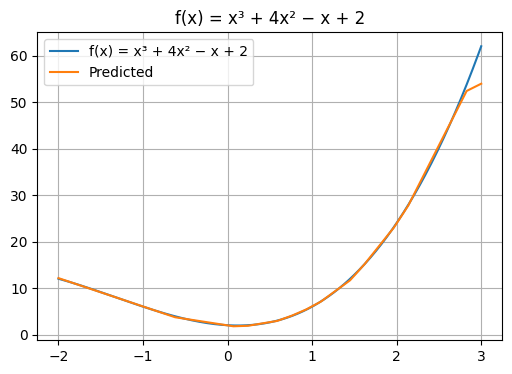

In [35]:
# Plot predicted values to same plot as the equation
# Implementation comes this cell
plt.figure(figsize=(6, 4))
plt.plot(X, y, label='f(x) = x³ + 4x² − x + 2')
plt.plot(X_new, y_new_predicted, label='Predicted')
plt.title("f(x) = x³ + 4x² − x + 2")
plt.grid(True)
plt.legend()
plt.show()

__Conclusion__

__NOTE: Conclusion is one evaluation criterion for the exercise, so pay attention to writing this__

Write conclusion:
- How number of nodes in hidden layer affects the results?
More nodes (and more hidden layers) allow the model to learn more complex patterns. In my experiments, two hidden layers with 4 and 8 nodes gave the best result at 200 epochs  The results were also not consistent between runs, because the model starts with random weights each time.

- How the number of epochs affects the results?
More epochs give the model more time to learn. With few epochs the loss was high which means the model was underfitting. Within the 50–200 range given in the exercise, 200 epochs gave the best results. I also tried more epochs, and at 500 epochs I found better results, so the model was still improving at 200 epochs. Train and test loss stayed close in all runs, so there was no overfitting.

- What you learn in this exercise?
I am a beginner in ML, and this exercise helped me understand the basics of how the number of hidden layers, nodes and epochs affect a neural network. I learned that there is no fixed rule for choosing these hyperparameters, and the best values have to be found by experimenting.

- Did you have difficulties in the exercise?
I am not from an ML background, so at times it was difficult to understand the nuances of neural networks and the different terms. Testing many combinations of hidden layers, nodes and epochs, and making sense of the results, was also challenging as a new learner, especially because the results changed between runs.